<a href="https://colab.research.google.com/github/priyasahani-25/Clean-Water-Sanitation/blob/main/Clean_Water_and_Sanitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORTING** **LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# **LOADING AND EXPLORING THE DATASET**

In [ ]:
df = pd.read_csv('/content/water_potability.csv')

print("Raw dataset")
print(df)

print("\n First 5 rows")
print(df.head())

print("\n Dataset Shape ")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n Column Info ")
print(df.info())

print("\n Statistical Summary ")
print(df.describe().round(2))

print("\n Missing Values per Column ")
print(df.isnull().sum())

Raw dataset
            ph    Hardness        Solids  Chloramines     Sulfate  \
0          NaN  204.890455  20791.318981     7.300212  368.516441   
1     3.716080  129.422921  18630.057858     6.635246         NaN   
2     8.099124  224.236259  19909.541732     9.275884         NaN   
3     8.316766  214.373394  22018.417441     8.059332  356.886136   
4     9.092223  181.101509  17978.986339     6.546600  310.135738   
...        ...         ...           ...          ...         ...   
3271  4.668102  193.681735  47580.991603     7.166639  359.948574   
3272  7.808856  193.553212  17329.802160     8.061362         NaN   
3273  9.419510  175.762646  33155.578218     7.350233         NaN   
3274  5.126763  230.603758  11983.869376     6.303357         NaN   
3275  7.874671  195.102299  17404.177061     7.509306         NaN   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       564.308654       10.379783        86.990970   2.963135           0  
1    

# **CLEANING THE DATA**

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)
print("Missing values left:", df.isnull().sum().sum())
print(f"Clean dataset: {df.shape[0]} rows")
print(df['Potability'].value_counts())

Missing values left: 0
Clean dataset: 3276 rows
Potability
0    1998
1    1278
Name: count, dtype: int64


# **VISUALIZING THE TRENDS AND PATTERNS**

In [ ]:
features = ['ph', 'Hardness', 'Solids', 'Chloramines',
            'Sulfate', 'Conductivity', 'Organic_carbon',
            'Trihalomethanes', 'Turbidity']

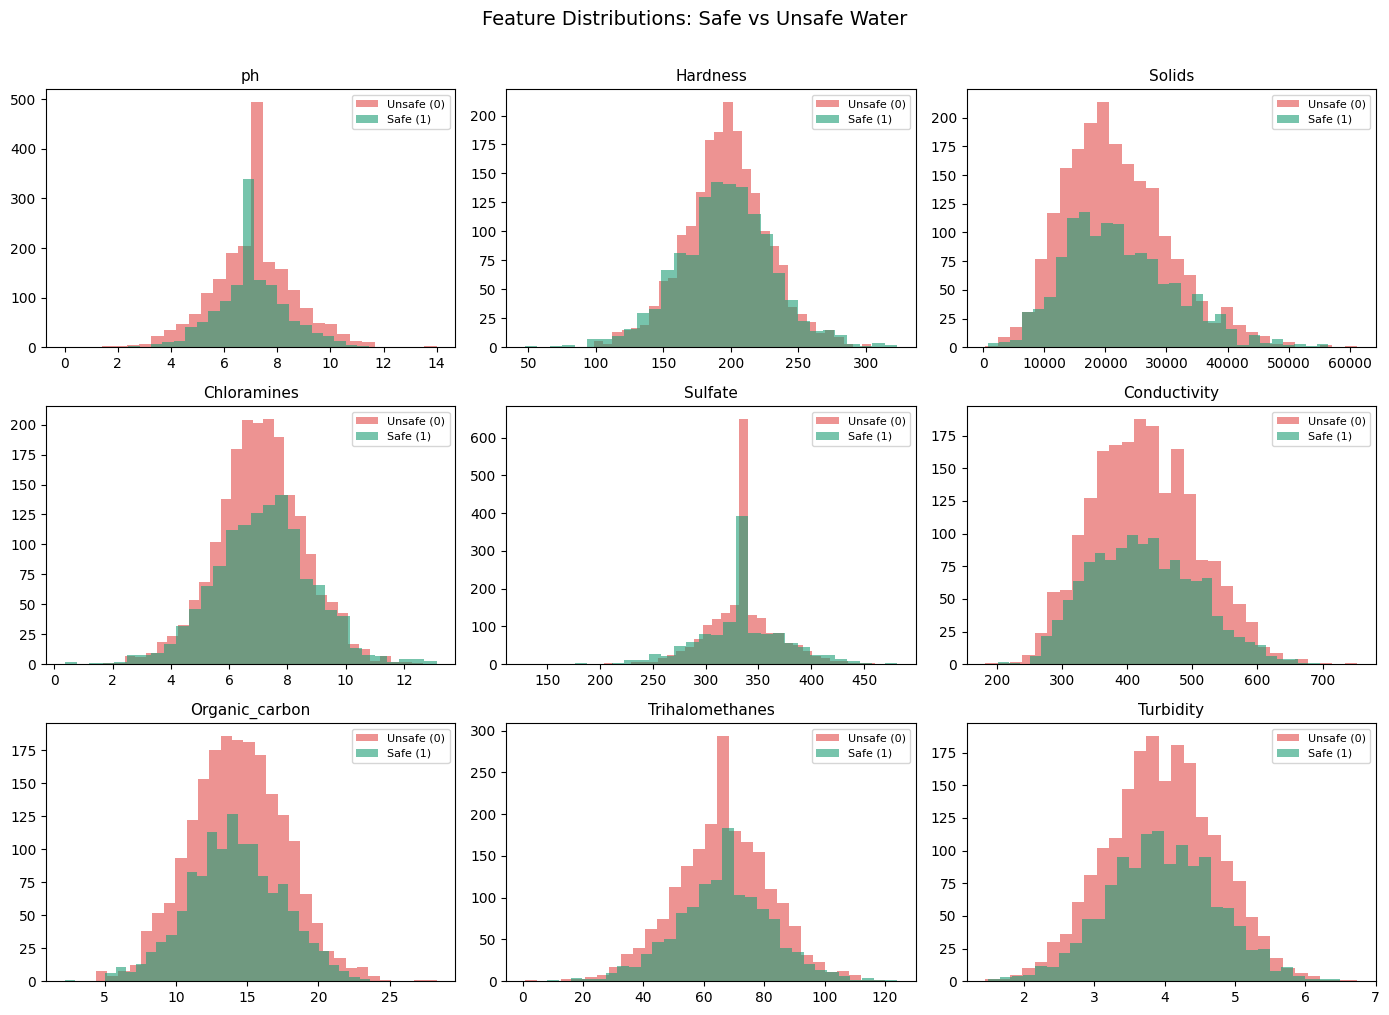

✅ Saved: distributions.png


In [ ]:
# Distribution of each feature split by potability
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    safe = df[df['Potability'] == 1][col]
    unsafe = df[df['Potability'] == 0][col]
    axes[i].hist(unsafe, bins=30, alpha=0.6, color='#E24B4A', label='Unsafe (0)')
    axes[i].hist(safe,   bins=30, alpha=0.6, color='#1D9E75', label='Safe (1)')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Safe vs Unsafe Water', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: distributions.png")

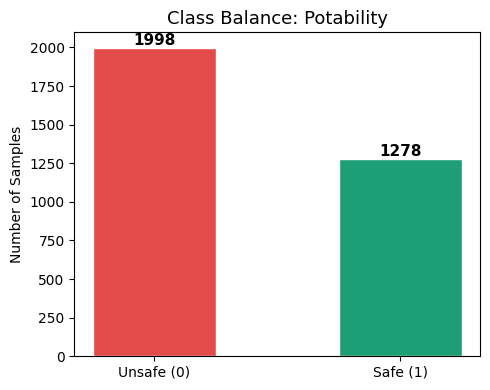

✅ Saved: class_balance.png


In [ ]:
# Potability class balance (bar chart)
plt.figure(figsize=(5, 4))
counts = df['Potability'].value_counts()
bars = plt.bar(['Unsafe (0)', 'Safe (1)'], counts.values,
               color=['#E24B4A', '#1D9E75'], edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', fontsize=11, fontweight='bold')
plt.title('Class Balance: Potability', fontsize=13)
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: class_balance.png")

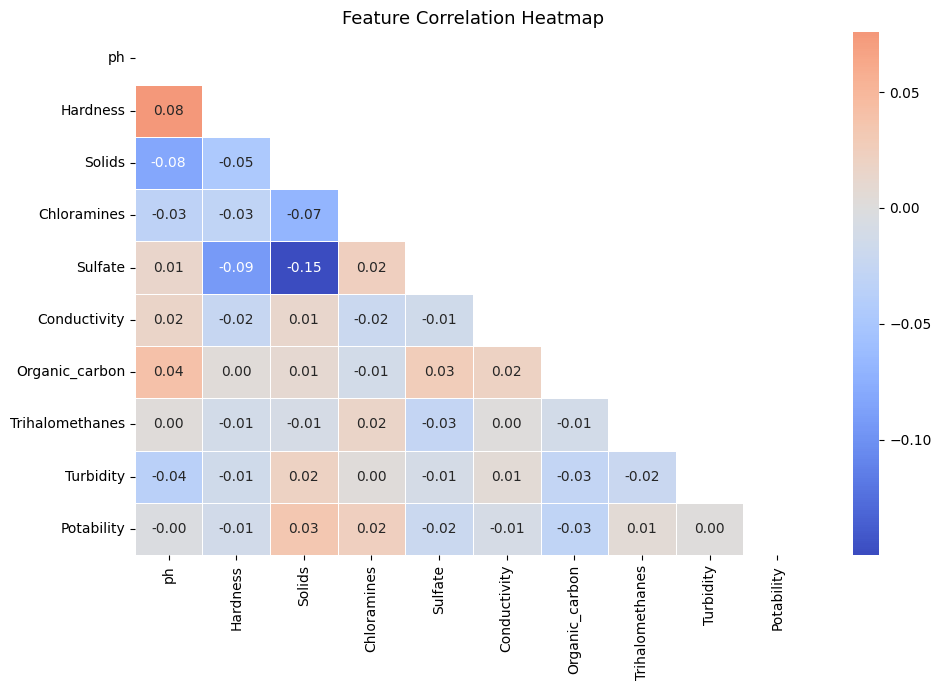

✅ Saved: correlation_heatmap.png


In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap.png")

# **PREPARING FEATURES AND LABELS**

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Potability'])
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n── Train/Test Split ──")
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


── Train/Test Split ──
Training samples : 2620
Testing  samples : 656


# **MODEL BUILDING**

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)
print("\n✅ Model trained successfully.")

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


✅ Model trained successfully.


# **EVALUATION AND RESULT VISUALIZATION**

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"\n── Model Accuracy: {acc * 100:.2f}% ──")
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
      target_names=['Unsafe (0)', 'Safe (1)']))


── Model Accuracy: 67.84% ──

── Classification Report ──
              precision    recall  f1-score   support

  Unsafe (0)       0.67      0.92      0.78       400
    Safe (1)       0.71      0.30      0.42       256

    accuracy                           0.68       656
   macro avg       0.69      0.61      0.60       656
weighted avg       0.69      0.68      0.64       656



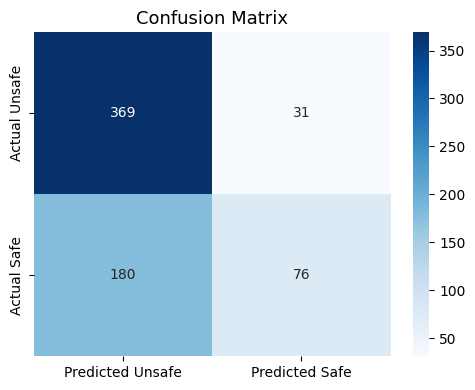

✅ Saved: confusion_matrix.png


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Unsafe', 'Predicted Safe'],
            yticklabels=['Actual Unsafe', 'Actual Safe'])
plt.title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix.png")

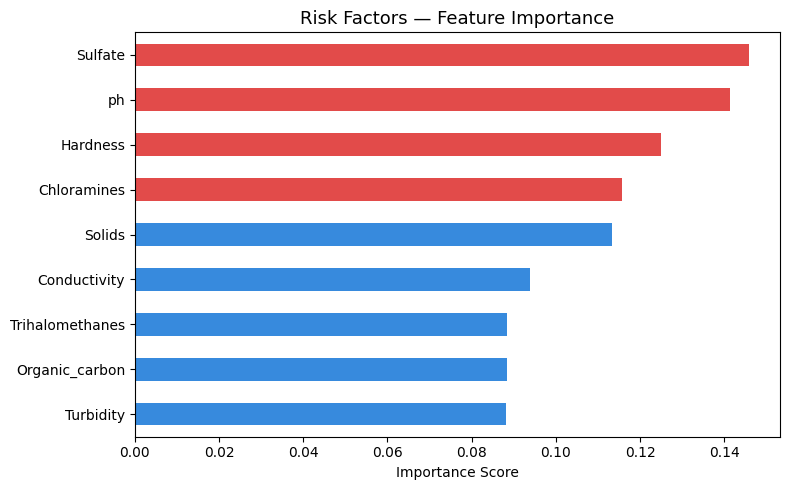

✅ Saved: feature_importance.png


In [ ]:
# Feature importance chart
importances = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#E24B4A' if v > importances.median() else '#378ADD'
          for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Risk Factors — Feature Importance', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

# **PREDICTING ON NEW SAMPLES**

In [ ]:
new_sample = pd.DataFrame([{
    'ph': 7.2,
    'Hardness': 180.0,
    'Solids': 15000.0,
    'Chloramines': 7.5,
    'Sulfate': 330.0,
    'Conductivity': 400.0,
    'Organic_carbon': 14.0,
    'Trihalomethanes': 70.0,
    'Turbidity': 3.8
}])

In [ ]:
new_scaled = scaler.transform(new_sample)
prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0][1]

print("\n── Prediction for New Water Sample ──")
print(f"Result      : {'✅ SAFE to drink' if prediction == 1 else '❌ NOT safe to drink'}")
print(f"Confidence  : {probability * 100:.1f}% probability of being safe")


── Prediction for New Water Sample ──
Result      : ❌ NOT safe to drink
Confidence  : 34.7% probability of being safe
